Import the libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Read the dataset.

In [2]:
df = pd.read_csv('Datasets/data_science_job.csv')
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
11284,5471,city_103,0.920,NaN,No relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,25.0,1.0
653,22348,city_19,0.682,Male,No relevent experience,Full time course,Graduate,STEM,9.0,NaN,NaN,42.0,0.0
18050,17088,city_103,0.920,NaN,No relevent experience,Full time course,Graduate,STEM,1.0,5000-9999,NaN,3.0,1.0
14863,9389,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,8.0,10000+,Pvt Ltd,51.0,0.0
6970,24089,city_21,0.624,Female,Has relevent experience,no_enrollment,Graduate,STEM,0.0,10/49,Pvt Ltd,16.0,1.0


Find the percentage misiing data in each column.

In [3]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

Find the shape of the dataset.

In [4]:
df.shape

(19158, 13)

Find the column in which missing data is less than 5%.

In [5]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]

cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

Samples of those columns.

In [6]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
11064,0.698,Full time course,Graduate,5.0,17.0
15438,0.923,no_enrollment,Graduate,20.0,125.0
4734,0.624,no_enrollment,Graduate,6.0,99.0
15396,0.926,no_enrollment,Masters,3.0,7.0
5477,0.624,no_enrollment,Graduate,4.0,28.0


Counts of the data in education column.

In [7]:
df['education_level'].value_counts()

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

Ratio of filled data to total data.

In [8]:
len(df[cols].dropna())/len(df)

0.8968577095730244

Taking only filled data to a new dataset as a process of CCA.

In [9]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

Plotting the graph.

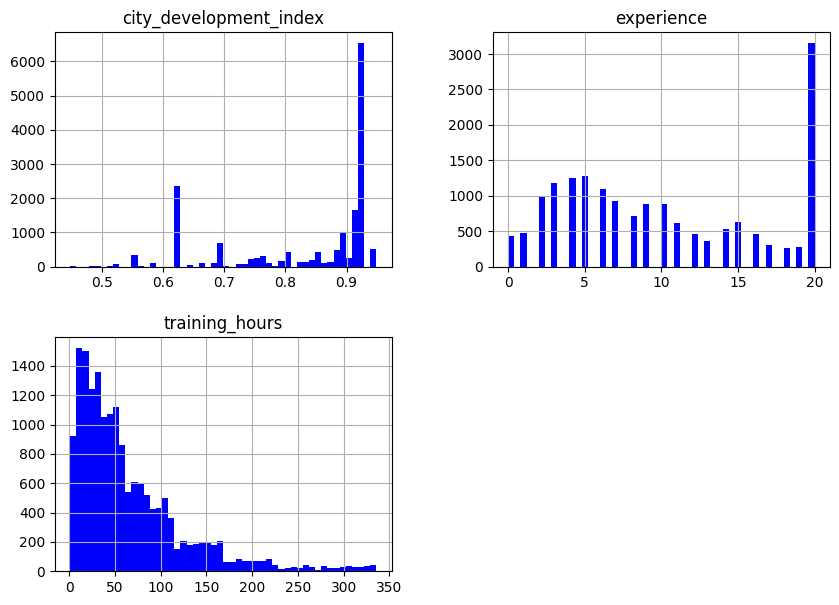

In [10]:
new_df.hist(bins = 50, figsize = (10, 7), color = 'blue')
plt.show()

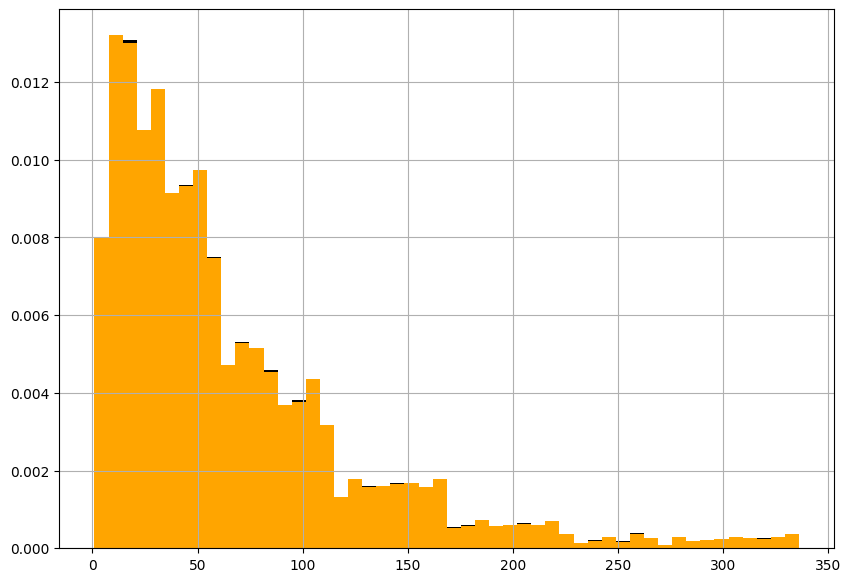

In [11]:
fig = plt.figure(figsize = (10, 7))
ax = fig.add_subplot(111)

df['training_hours'].hist(bins=50, density=True, color = 'black', ax = ax)

new_df['training_hours'].hist(bins=50, density=True, color = 'orange', ax = ax)
plt.show()

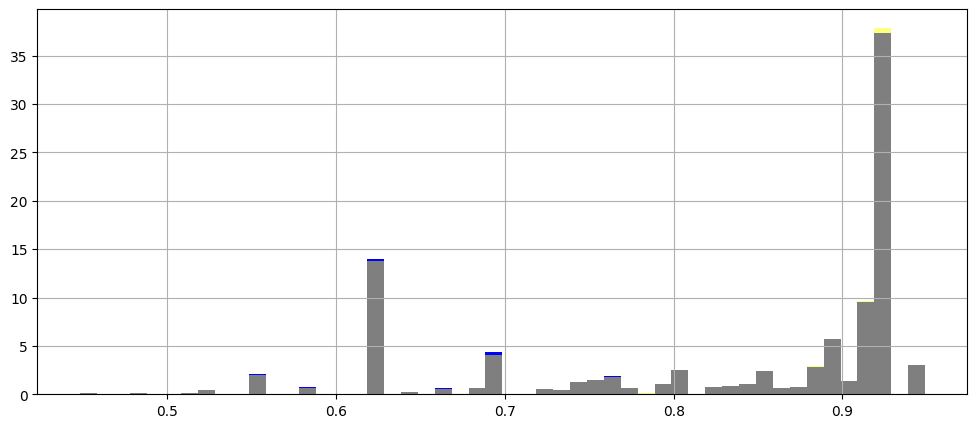

In [12]:
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(111)

df['city_development_index'].hist(bins=50, density=True, color = 'blue', ax = ax)
new_df['city_development_index'].hist(bins=50, density=True, color = 'yellow', ax = ax, alpha = 0.5)
plt.show()

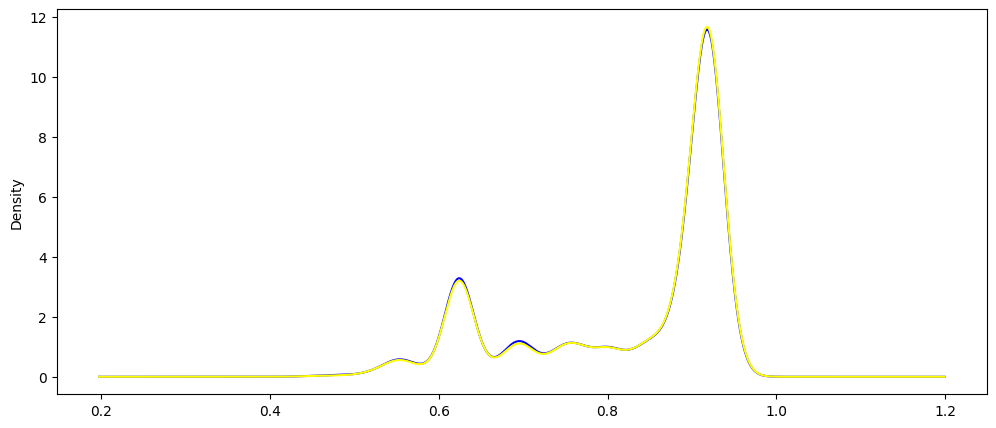

In [13]:
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(111)
df['city_development_index'].plot.density(color = 'blue',ax=ax)
new_df['city_development_index'].plot.density(color = 'yellow',ax=ax)
plt.show()

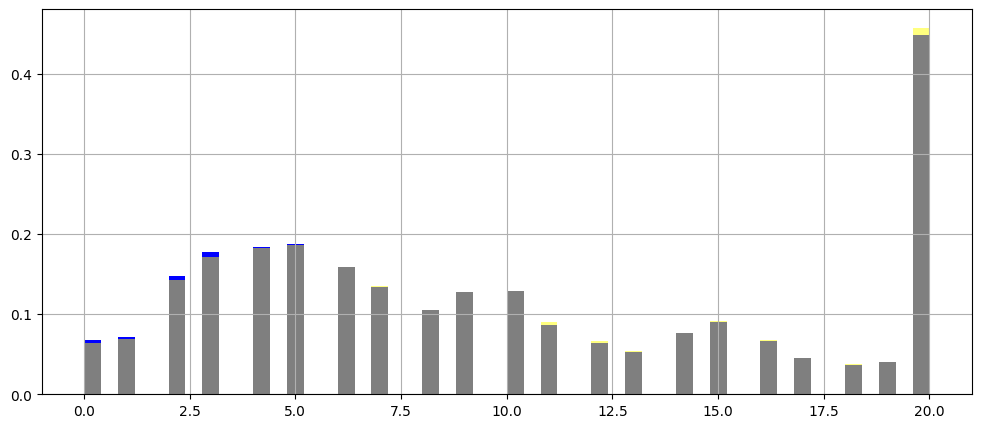

In [14]:
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(111)

df['experience'].hist(bins=50, density=True, color = 'blue', ax = ax)
new_df['experience'].hist(bins=50, density=True, color = 'yellow', ax = ax, alpha = 0.5)
plt.show()


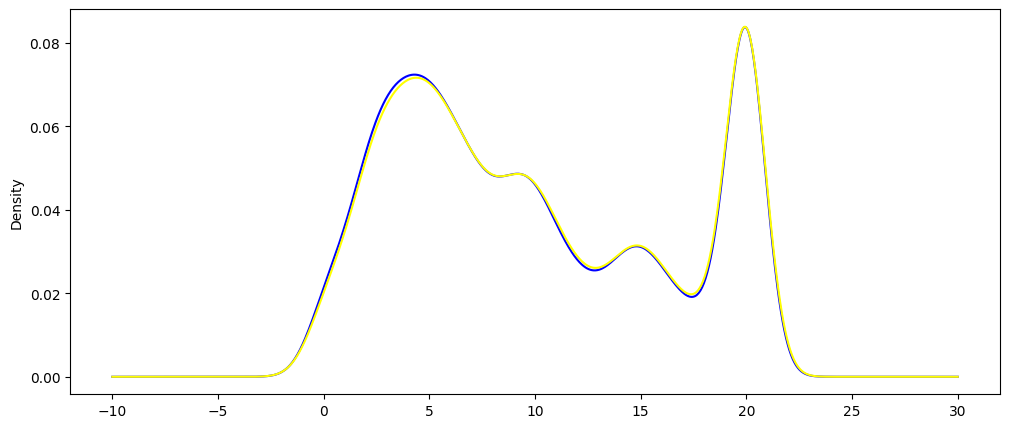

In [15]:
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(111)

df['experience'].plot.density(color = 'blue',ax=ax)
new_df['experience'].plot.density(color = 'yellow',ax=ax)
plt.show()

Compare before and after CCA results.

In [16]:
temp = pd.concat([
    df['enrolled_university'].value_counts() / len(df),
    new_df['enrolled_university'].value_counts() / len(df)
], axis=1)

temp.columns = ['original', 'cca']
temp


,original,cca
enrolled_university,,
no_enrollment,0.721213,0.659359
Full time course,0.196106,0.180029
Part time course,0.062533,0.057469


In [17]:
temp = pd.concat([
    df['education_level'].value_counts() / len(df),
    new_df['education_level'].value_counts() / len(df)
], axis=1)      
temp.columns = ['original', 'cca']
temp

,original,cca
education_level,,
Graduate,0.605387,0.555904
Masters,0.227633,0.209938
High School,0.105282,0.096304
Phd,0.021610,0.019835
Primary School,0.016077,0.014876
